In [7]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import json
from torch.utils.data import DataLoader, TensorDataset

# Set device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

Device: cuda


In [8]:
TENSOR_DIR = 'tensors_gpt/'

X_test = np.load(TENSOR_DIR + 'X_test.npy')
y_test = np.load(TENSOR_DIR + 'y_test.npy')
mask_test = np.load(TENSOR_DIR + 'mask_test.npy')

# Load metadata to get feature names
with open('tensors_rep/metadata.json', 'r') as f:
    metadata = json.load(f)
all_features = metadata['all_features']

# Drop the same features as during training
drop_features = ['respiratory_rate', 'sbp', 'wbc', 'time_since_last_age', 'time_since_last_gender']
drop_indices = [all_features.index(f) for f in drop_features]
keep_indices = [i for i in range(len(all_features)) if i not in drop_indices]
feature_names_clean = [all_features[i] for i in keep_indices]

X_test_clean = X_test[:, :, keep_indices]

# (Optional) apply the same clipping as training – adjust if needed
# For simplicity we skip clipping here, but you can add it if required.

print(f"X_test shape: {X_test_clean.shape}")
print(f"Number of features: {len(feature_names_clean)}")

X_test shape: (9805, 48, 25)
Number of features: 25


In [9]:
from torch.utils.data import Dataset, DataLoader
class ICUDataset(Dataset):
    def __init__(self, X, mask, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.mask = torch.tensor(mask.astype(bool), dtype=torch.bool)
        self.y = torch.tensor(y, dtype=torch.float32)
    
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        return self.X[idx], self.mask[idx], self.y[idx]

In [10]:
test_dataset = ICUDataset(X_test_clean, mask_test, y_test)

# Create loader
test_loader = DataLoader(
    test_dataset, 
    batch_size=64, 
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

In [15]:
DEVICE = torch.device("cpu")
print(f"Device: {DEVICE}")

Device: cpu


In [16]:
from Scripts.gpt import ChainOfInfluence

# Get input dimension from your fixed tensors
input_dim = X_test_clean.shape[2]   # number of features after cleaning

model = ChainOfInfluence(
    n_features=input_dim,
    d_model=64,
    lstm_hidden=32,
    n_heads=4,
    n_layers=2,
    dim_feedforward=256,
    dropout=0.2,
    max_len=48,               # number of time steps
    use_mask_as_padding=False  # keep False for forward-filled data
).to(DEVICE)

WEIGHTS_PATH = 'Weights/best_model_gpt_fixed.pt'
model.load_state_dict(torch.load(WEIGHTS_PATH, map_location=DEVICE))
model.eval()
print("Model loaded")

Model loaded


In [17]:
dead_idx = np.where(y_test == 1)[0]

X_test_dead = X_test_clean[dead_idx]
mask_test_dead = mask_test[dead_idx]
y_test_dead = y_test[dead_idx]

print(f"Dead patients: {len(dead_idx)} / {len(y_test)}")

# Dead-only loader for attention summary
dead_dataset = ICUDataset(X_test_dead, mask_test_dead, y_test_dead)
dead_loader = DataLoader(
    dead_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

Dead patients: 1076 / 9805


In [18]:
from faithfulness_tests import (
    erasure_experiment,
    peak_erasure_experiment,
    get_attention_and_prediction,
    print_attention_summary
)

# Dead-only attention summary
print_attention_summary(model, dead_loader, DEVICE, num_patients=min(200, len(y_test_dead)))

# Dead-only peak erasure
peak_results_dead = peak_erasure_experiment(
    model,
    X_test_dead,
    mask_test_dead,
    DEVICE,
    batch_size=64
)

# Dead-only top-k erasure
erasure_results_dead = erasure_experiment(
    model,
    X_test_dead,
    mask_test_dead,
    DEVICE,
    top_k=5,
    batch_size=64
)


ATTENTION SUMMARY (n=256)
  Mean peak attention: 0.1009
  Std peak attention:  0.0567
  Mean entropy:        3.0428
  Std entropy:         0.4967
  Min entropy:         1.7296
  Max entropy:         3.7456

  Uniform baseline entropy: 3.8712
  ✅ Attention is focused (lower entropy than uniform)

PEAK ERASURE EXPERIMENT (single timestep)

Results:
  Mean Δ after erasing peak timestep: 0.0041
  Std Δ: 0.0088
  Fraction with decreased risk: 80.7%
  Fraction with increased risk: 19.3%
  ✅ Erasing peak timestep decreases mortality prediction (expected)

ERASURE EXPERIMENT (top_k=5)
Patients: 1076, Time steps: 48
Baseline mortality probability: 0.7081

Results:
  Mean Δ (attention-guided erase): 0.0597
  Mean Δ (random erase):           0.0187
  Ratio (attn/random):             3.196
  Wilcoxon p (greater):            0.0000
  ✅ Attention is FAITHFUL (erasing attended steps hurts more)


In [19]:
def show_dead_patient_examples(model, X, mask, y, device, top_k=3, num_examples=5):
    """
    Show detailed before/after for dead patients only.
    """
    # Filter to dead patients only (y == 1)
    if isinstance(y, np.ndarray):
        dead_indices = np.where(y == 1)[0]
    else:
        dead_indices = np.where(y.numpy() == 1)[0]
    
    X_dead = X[dead_indices]
    mask_dead = mask[dead_indices]
    y_dead = y[dead_indices]
    
    print(f"Total dead patients: {len(dead_indices)}")
    print(f"Showing {min(num_examples, len(dead_indices))} examples\n")
    
    # Get attention and predictions for dead patients
    baseline_probs, attn = get_attention_and_prediction(model, X_dead, mask_dead, device, batch_size=64)
    
    # Find top-k indices
    top_k_indices = np.argsort(attn, axis=1)[:, -top_k:]
    
    # FIXED: Proper erasure with masking
    mask_erased = mask_dead.copy()
    X_erased = X_dead.copy()
    
    for i in range(len(X_dead)):
        mask_erased[i, top_k_indices[i]] = 0  # Remove from mask
        X_erased[i, top_k_indices[i], :] = 0.0
    
    erased_probs, _ = get_attention_and_prediction(model, X_erased, mask_erased, device, batch_size=64)
    
    # Show first num_examples dead patients
    for i in range(min(num_examples, len(X_dead))):
        delta = baseline_probs[i] - erased_probs[i]
        
        print("="*60)
        print(f"DEAD PATIENT {i} (Original index: {dead_indices[i]})")
        print("="*60)
        print(f"Baseline mortality probability: {baseline_probs[i]:.4f} ({baseline_probs[i]*100:.2f}%)")
        print(f"After erasing top-{top_k} steps:  {erased_probs[i]:.4f} ({erased_probs[i]*100:.2f}%)")
        print(f"Change: {delta:+.4f} ({delta*100:+.2f} percentage points)")
        
        if delta > 0:
            print(f"➡️ Mortality risk DECREASED by {delta*100:.2f}% (Expected for faithful attention)")
        elif delta < 0:
            print(f"⚠️ Mortality risk INCREASED by {abs(delta)*100:.2f}% (Model uses other signals)")
        else:
            print(f"➡️ No change (Attention may not be used)")
        
        print(f"\nAttention distribution:")
        print(f"  Peak attention: {attn[i].max():.4f} at time step {np.argmax(attn[i])}")
        print(f"  Top-{top_k} attended time steps: {top_k_indices[i]}")
        print(f"  Attention values at top-{top_k}: {[f'{attn[i][t]:.4f}' for t in top_k_indices[i]]}")
        print(f"  Mean attention: {attn[i].mean():.4f}")
        print()

# Run for dead patients only
show_dead_patient_examples(model, X_test_clean, mask_test, y_test, DEVICE, top_k=3, num_examples=5)

Total dead patients: 1076
Showing 5 examples

DEAD PATIENT 0 (Original index: 6)
Baseline mortality probability: 0.9137 (91.37%)
After erasing top-3 steps:  0.9078 (90.78%)
Change: +0.0059 (+0.59 percentage points)
➡️ Mortality risk DECREASED by 0.59% (Expected for faithful attention)

Attention distribution:
  Peak attention: 0.0521 at time step 15
  Top-3 attended time steps: [14 16 15]
  Attention values at top-3: ['0.0489', '0.0490', '0.0521']
  Mean attention: 0.0208

DEAD PATIENT 1 (Original index: 10)
Baseline mortality probability: 0.8457 (84.57%)
After erasing top-3 steps:  0.8231 (82.31%)
Change: +0.0226 (+2.26 percentage points)
➡️ Mortality risk DECREASED by 2.26% (Expected for faithful attention)

Attention distribution:
  Peak attention: 0.0575 at time step 8
  Top-3 attended time steps: [15  7  8]
  Attention values at top-3: ['0.0521', '0.0556', '0.0575']
  Mean attention: 0.0208

DEAD PATIENT 2 (Original index: 12)
Baseline mortality probability: 0.4653 (46.53%)
After 

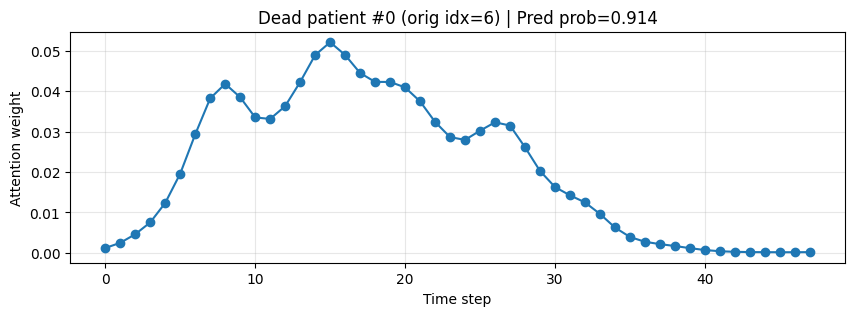

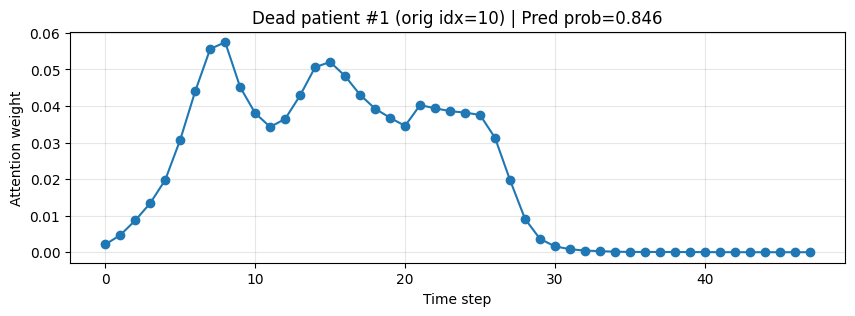

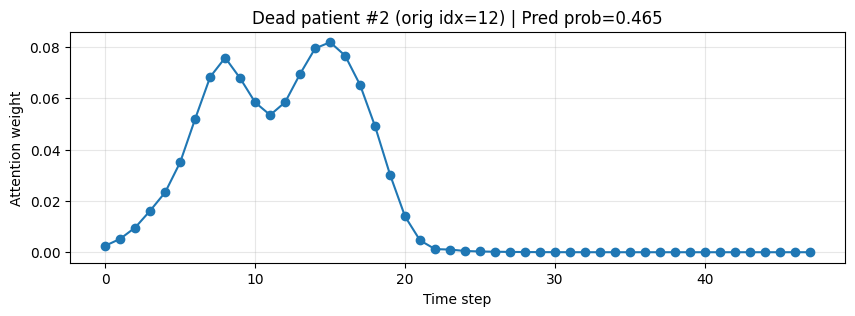

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from faithfulness_tests import get_attention_and_prediction

def plot_dead_patient_attention(model, X, mask, y, device, dead_patient_number=0):
    # dead_patient_number = index within dead-patient subset (0,1,2,...)
    dead_idx = np.where(y == 1)[0]
    if len(dead_idx) == 0:
        print("No dead patients found.")
        return
    
    if dead_patient_number >= len(dead_idx):
        print(f"dead_patient_number out of range. Max is {len(dead_idx)-1}")
        return
    
    original_idx = dead_idx[dead_patient_number]
    x_one = X[original_idx:original_idx+1]
    m_one = mask[original_idx:original_idx+1]
    
    probs, attn = get_attention_and_prediction(model, x_one, m_one, device, batch_size=1)
    a = attn[0]  # (T,)
    
    plt.figure(figsize=(10, 3))
    plt.plot(np.arange(len(a)), a, marker="o")
    plt.title(f"Dead patient #{dead_patient_number} (orig idx={original_idx}) | Pred prob={probs[0]:.3f}")
    plt.xlabel("Time step")
    plt.ylabel("Attention weight")
    plt.grid(alpha=0.3)
    plt.show()

# Example:
for i in range(3):  # Show first 3 dead patients
    plot_dead_patient_attention(model, X_test_clean, mask_test, y_test, DEVICE, dead_patient_number=i)

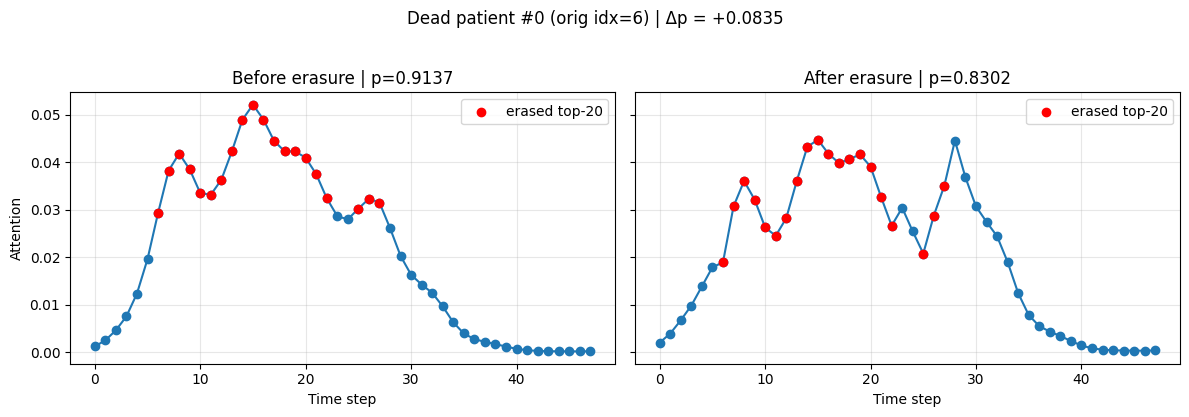

Original idx: 6
Erased top-20 timesteps: [ 6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 25 26 27]
Probability before: 0.9137
Probability after : 0.8302
Delta (before-after): +0.0835


In [41]:
# ...existing code...
import numpy as np
import matplotlib.pyplot as plt
from faithfulness_tests import get_attention_and_prediction

def visualize_before_after_erasure_one_dead_topk(
    model, X, mask, y, device, dead_patient_number=0, top_k=5
):
    dead_idx = np.where(y == 1)[0]
    if len(dead_idx) == 0:
        print("No dead patients found.")
        return

    if dead_patient_number >= len(dead_idx):
        print(f"dead_patient_number out of range. Max is {len(dead_idx)-1}")
        return

    orig_idx = dead_idx[dead_patient_number]

    x_one = X[orig_idx:orig_idx+1].copy()
    m_one = mask[orig_idx:orig_idx+1].copy()

    # Before erasure
    p_before, a_before = get_attention_and_prediction(model, x_one, m_one, device, batch_size=1)
    a0 = a_before[0]  # (T,)

    # Top-k timesteps (highest attention)
    top_idx = np.argsort(a0)[-top_k:]

    # After erasure (zero + mask out top-k timesteps)
    x_erased = x_one.copy()
    m_erased = m_one.copy()
    x_erased[0, top_idx, :] = 0.0
    m_erased[0, top_idx] = 0

    p_after, a_after = get_attention_and_prediction(model, x_erased, m_erased, device, batch_size=1)
    a1 = a_after[0]

    delta = float(p_before[0] - p_after[0])

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

    axes[0].plot(np.arange(len(a0)), a0, marker="o")
    axes[0].scatter(top_idx, a0[top_idx], color="red", zorder=3, label=f"erased top-{top_k}")
    axes[0].set_title(f"Before erasure | p={p_before[0]:.4f}")
    axes[0].set_xlabel("Time step")
    axes[0].set_ylabel("Attention")
    axes[0].grid(alpha=0.3)
    axes[0].legend()

    axes[1].plot(np.arange(len(a1)), a1, marker="o")
    axes[1].scatter(top_idx, a1[top_idx], color="red", zorder=3, label=f"erased top-{top_k}")
    axes[1].set_title(f"After erasure | p={p_after[0]:.4f}")
    axes[1].set_xlabel("Time step")
    axes[1].grid(alpha=0.3)
    axes[1].legend()

    plt.suptitle(
        f"Dead patient #{dead_patient_number} (orig idx={orig_idx}) | Δp = {delta:+.4f}",
        y=1.03
    )
    plt.tight_layout()
    plt.show()

    print(f"Original idx: {orig_idx}")
    print(f"Erased top-{top_k} timesteps: {np.sort(top_idx)}")
    print(f"Probability before: {p_before[0]:.4f}")
    print(f"Probability after : {p_after[0]:.4f}")
    print(f"Delta (before-after): {delta:+.4f}")

# Example
visualize_before_after_erasure_one_dead_topk(
    model, X_test_clean, mask_test, y_test, DEVICE, dead_patient_number=0, top_k=20
)
# ...existing code...

In [ ]:
# ...existing code...
import numpy as np
import torch

def _extract_main_output(output):
    """Pick prediction tensor from model output (tensor / tuple / list / dict)."""
    if torch.is_tensor(output):
        return output
    if isinstance(output, (tuple, list)):
        for item in output:
            if torch.is_tensor(item):
                return item
    if isinstance(output, dict):
        for k in ["logits", "pred", "prediction", "y_hat", "output"]:
            if k in output and torch.is_tensor(output[k]):
                return output[k]
        for v in output.values():
            if torch.is_tensor(v):
                return v
    raise ValueError("Could not extract tensor output from model forward pass.")

@torch.no_grad()
def get_probs_from_loader(model, loader, device, apply_sigmoid=True):
    model.eval()
    probs_all, y_all = [], []

    for xb, mb, yb in loader:
        xb = xb.to(device)
        mb = mb.to(device)

        # Try forward with mask first, then without
        try:
            out = model(xb, mb)
        except TypeError:
            out = model(xb)

        out = _extract_main_output(out).squeeze(-1)  # [B] or [B,1] -> [B]

        if apply_sigmoid:
            p = torch.sigmoid(out)
        else:
            p = out

        probs_all.append(p.detach().cpu().numpy())
        y_all.append(yb.detach().cpu().numpy())

    probs = np.concatenate(probs_all).astype(float)
    y_true = np.concatenate(y_all).astype(int)
    return y_true, probs

# Example: CoI
y_true, probs_coi = get_probs_from_loader(model, test_loader, DEVICE, apply_sigmoid=True)

# Example: TF-CAM (if loaded as model_tfcam)
# y_true_tf, probs_tfcam = get_probs_from_loader(model_tfcam, test_loader, DEVICE, apply_sigmoid=True)

# Then:
# plot_roc_comparison(y_true, probs_coi, probs_tfcam)
# ...existing code...

In [46]:
# ...existing code...
import numpy as np
from scipy.stats import wilcoxon

def get_tp_fn_indices(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = (y_prob >= threshold).astype(int)

    tp_idx = np.where((y_true == 1) & (y_pred == 1))[0]
    fn_idx = np.where((y_true == 1) & (y_pred == 0))[0]
    return tp_idx, fn_idx

@torch.no_grad()
def erasure_deltas_for_indices(model, X, mask, indices, device, top_k=5, n_random_trials=20, seed=0):
    rng = np.random.default_rng(seed)
    deltas_attn = []
    deltas_rand = []

    for idx in indices:
        x_one = X[idx:idx+1].copy()
        m_one = mask[idx:idx+1].copy()

        # baseline
        p_before, a_before = get_attention_and_prediction(model, x_one, m_one, device, batch_size=1)
        a0 = a_before[0]

        # attention-guided erasure
        top_idx = np.argsort(a0)[-top_k:]
        x_attn = x_one.copy()
        m_attn = m_one.copy()
        x_attn[0, top_idx, :] = 0.0
        m_attn[0, top_idx] = 0

        p_after_attn, _ = get_attention_and_prediction(model, x_attn, m_attn, device, batch_size=1)
        deltas_attn.append(float(p_before[0] - p_after_attn[0]))

        # random erasure (average over several random draws)
        rand_deltas_i = []
        T = x_one.shape[1]
        for _ in range(n_random_trials):
            rand_idx = rng.choice(T, size=top_k, replace=False)
            x_rand = x_one.copy()
            m_rand = m_one.copy()
            x_rand[0, rand_idx, :] = 0.0
            m_rand[0, rand_idx] = 0

            p_after_rand, _ = get_attention_and_prediction(model, x_rand, m_rand, device, batch_size=1)
            rand_deltas_i.append(float(p_before[0] - p_after_rand[0]))

        deltas_rand.append(float(np.mean(rand_deltas_i)))

    deltas_attn = np.asarray(deltas_attn, dtype=float)
    deltas_rand = np.asarray(deltas_rand, dtype=float)
    return deltas_attn, deltas_rand

def summarize_group(model, X, mask, y, indices, device, top_k=5, n_random_trials=20):
    d_attn, d_rand = erasure_deltas_for_indices(
        model, X, mask, indices, device, top_k=top_k, n_random_trials=n_random_trials
    )

    mean_attn = d_attn.mean()
    mean_rand = d_rand.mean()
    rho = mean_attn / mean_rand if mean_rand != 0 else np.nan
    p_w = wilcoxon(d_attn, d_rand, alternative="greater").pvalue

    return {
        "N": len(indices),
        "mean_attn": mean_attn,
        "mean_rand": mean_rand,
        "rho": rho,
        "p_wilcoxon": p_w,
        "d_attn": d_attn,
        "d_rand": d_rand,
    }

# Baseline predictions on the full test set
y_true_all, probs_all = get_probs_from_loader(model, test_loader, DEVICE, apply_sigmoid=True)

# TP / FN indices
tp_idx, fn_idx = get_tp_fn_indices(y_true_all, probs_all, threshold=0.5)

# Summaries
tp_res = summarize_group(model, X_test_clean, mask_test, y_test, tp_idx, DEVICE, top_k=5, n_random_trials=20)
fn_res = summarize_group(model, X_test_clean, mask_test, y_test, fn_idx, DEVICE, top_k=5, n_random_trials=20)

print("TP:", tp_res)
print("FN:", fn_res)

# Optional: print values ready for the table
print(f"TP all | attn={tp_res['mean_attn']:.4f} | rand={tp_res['mean_rand']:.4f} | rho={tp_res['rho']:.3f} | p={tp_res['p_wilcoxon']:.4g} | N={tp_res['N']}")
print(f"FN all | attn={fn_res['mean_attn']:.4f} | rand={fn_res['mean_rand']:.4f} | rho={fn_res['rho']:.3f} | p={fn_res['p_wilcoxon']:.4g} | N={fn_res['N']}")
# ...existing code...

TP: {'N': 854, 'mean_attn': 0.07702719282350161, 'mean_rand': 0.023452344601341376, 'rho': 3.2844133127353063, 'p_wilcoxon': 6.287869625481486e-98, 'd_attn': array([ 6.13361597e-03,  3.11427712e-02,  2.11002529e-01,  7.24256635e-02,
        3.39603424e-03,  7.04496503e-02,  5.85228801e-02,  7.97390938e-04,
       -1.25042200e-02,  3.49751115e-02,  2.34691501e-02,  9.92125869e-02,
        7.13420510e-02, -2.02589631e-02,  1.73147380e-01,  4.13101912e-03,
        2.50148952e-01,  6.97833300e-02,  6.97277784e-02,  1.48859799e-01,
        1.05054289e-01,  1.53806686e-01,  2.59872079e-02,  3.31302285e-02,
        1.07716650e-01,  3.89845967e-02,  3.40819359e-03,  1.46417975e-01,
        6.35204911e-02,  1.57135129e-02,  8.42962265e-02,  4.52232957e-02,
        1.21072531e-02,  1.63980365e-01,  1.33483112e-01,  7.37509727e-02,
        4.17518079e-01,  3.72222662e-02,  5.04629016e-02,  7.21331835e-02,
        3.49236727e-02,  1.00840330e-02,  1.69134736e-02,  2.46062338e-01,
        8.3762407

In [48]:
import numpy as np
import torch
from scipy.stats import wilcoxon

def get_tp_fn_indices(y_true, y_prob, threshold=0.5):
    """Get indices of True Positives and False Negatives."""
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = (y_prob >= threshold).astype(int)

    tp_idx = np.where((y_true == 1) & (y_pred == 1))[0]
    fn_idx = np.where((y_true == 1) & (y_pred == 0))[0]
    return tp_idx, fn_idx

@torch.no_grad()
def original_swap_experiment_for_indices(
    model, X, mask, indices, device, top_k=3, S=5, seed=0
):
    """
    ORIGINAL swap experiment: swap ALL top-k time steps with random steps at once.
    
    For each patient:
      - find top-k attention timesteps
      - perform S independent random swaps (each time swapping ALL top-k positions)
      - compute:
          * attn_drop = mean(attn_before[top_k]) - mean(attn_after[top_k])
          * prob_change = |p_after - p_before|
    Returns per-patient arrays averaged over S swaps.
    """
    rng = np.random.default_rng(seed)
    attn_drops = []
    abs_prob_deltas = []

    for idx in indices:
        x_one = X[idx:idx+1].copy()
        m_one = mask[idx:idx+1].copy()

        # Baseline
        p_before, a_before = get_attention_and_prediction(
            model, x_one, m_one, device, batch_size=1
        )
        a0 = a_before[0]  # (T,)
        top_idx = np.argsort(a0)[-top_k:]

        patient_attn_drops = []
        patient_abs_dp = []

        T = x_one.shape[1]
        all_idx = np.arange(T)
        candidate_rand = np.setdiff1d(all_idx, top_idx)

        for _ in range(S):
            # Randomly select top_k positions to swap WITH
            # (swap each top-k position with a different random position)
            rand_idx = rng.choice(candidate_rand, size=top_k, replace=False)
            
            x_swapped = x_one.copy()
            m_swapped = m_one.copy()

            # Swap ALL top-k positions with selected random positions
            for i_top, i_rand in zip(top_idx, rand_idx):
                # Swap feature vectors
                tmp_x = x_swapped[0, i_top, :].copy()
                tmp_m = m_swapped[0, i_top].copy()

                x_swapped[0, i_top, :] = x_swapped[0, i_rand, :]
                m_swapped[0, i_top] = m_swapped[0, i_rand]

                x_swapped[0, i_rand, :] = tmp_x
                m_swapped[0, i_rand] = tmp_m

            p_after, a_after = get_attention_and_prediction(
                model, x_swapped, m_swapped, device, batch_size=1
            )
            a1 = a_after[0]

            # Attention drop on the original top-k set
            attn_drop = float(a0[top_idx].mean() - a1[top_idx].mean())
            patient_attn_drops.append(attn_drop)

            # Probability change magnitude
            abs_dp = float(abs(p_after[0] - p_before[0]))
            patient_abs_dp.append(abs_dp)

        attn_drops.append(float(np.mean(patient_attn_drops)))
        abs_prob_deltas.append(float(np.mean(patient_abs_dp)))

    return np.asarray(attn_drops, dtype=float), np.asarray(abs_prob_deltas, dtype=float)

def summarize_swap_group_original(model, X, mask, y, indices, device, top_k=3, S=5, seed=0):
    """Summarize swap results for a group of indices."""
    attn_drops, abs_dp = original_swap_experiment_for_indices(
        model, X, mask, indices, device, top_k=top_k, S=S, seed=seed
    )

    return {
        "N": len(indices),
        "mean_attn_drop": float(attn_drops.mean()),
        "frac_drop_gt_0": float((attn_drops > 0).mean()),
        "mean_abs_dp": float(abs_dp.mean()),
        "attn_drops": attn_drops,
        "abs_dp": abs_dp,
    }

# Run original swap experiment
print("Running ORIGINAL swap experiment (swap all top-k at once)...")
print("-" * 60)

tp_swap_original = summarize_swap_group_original(
    model, X_test_clean, mask_test, y_test, tp_idx, DEVICE, top_k=3, S=5, seed=0
)

fn_swap_original = summarize_swap_group_original(
    model, X_test_clean, mask_test, y_test, fn_idx, DEVICE, top_k=3, S=5, seed=0
)

print("\n" + "="*60)
print("ORIGINAL SWAP EXPERIMENT RESULTS")
print("="*60)
print(f"\nTP (True Positives, correctly predicted dead):")
print(f"  Mean attention drop at original top-k: {tp_swap_original['mean_attn_drop']:.4f}")
print(f"  Fraction with drop > 0:               {tp_swap_original['frac_drop_gt_0']:.3f}")
print(f"  Mean |Δ mortality probability|:       {tp_swap_original['mean_abs_dp']:.4f}")
print(f"  N = {tp_swap_original['N']}")

print(f"\nFN (False Negatives, missed dead):")
print(f"  Mean attention drop at original top-k: {fn_swap_original['mean_attn_drop']:.4f}")
print(f"  Fraction with drop > 0:               {fn_swap_original['frac_drop_gt_0']:.3f}")
print(f"  Mean |Δ mortality probability|:       {fn_swap_original['mean_abs_dp']:.4f}")
print(f"  N = {fn_swap_original['N']}")

Running ORIGINAL swap experiment (swap all top-k at once)...
------------------------------------------------------------

ORIGINAL SWAP EXPERIMENT RESULTS

TP (True Positives, correctly predicted dead):
  Mean attention drop at original top-k: 0.0388
  Fraction with drop > 0:               0.951
  Mean |Δ mortality probability|:       0.0193
  N = 854

FN (False Negatives, missed dead):
  Mean attention drop at original top-k: 0.0216
  Fraction with drop > 0:               0.977
  Mean |Δ mortality probability|:       0.0279
  N = 222
